# Employee Attrition Prediction using Machine Learning

## Internship Project – Week 2

### Objective
The objective of this project is to predict whether an employee is likely to leave the company based on various factors such as salary, work-life balance, job role, job satisfaction, years at the company, and performance.

In this notebook, we will:

- Load and explore the dataset
- Clean and preprocess the data
- Perform Exploratory Data Analysis (EDA)
- Build multiple Machine Learning models
- Compare model performance
- Identify important factors affecting employee attrition
- Provide HR recommendations based on the findings

In [1]:
# Employee Attrition Prediction
# Task 1 : Import Required Libraries
# Data Manipulation
import pandas as pd
import numpy as np
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")
# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier)
# Display graphs inside notebook
%matplotlib inline
# Set plotting style
sns.set(style="whitegrid")
print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load CSV file
df = pd.read_csv("HR_Attrition.csv")
# Display first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Display First 10 Rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
# Number of Rows and Columns
rows, columns = df.shape
print("Number of Rows :", rows)
print("Number of Columns :", columns)

Number of Rows : 1470
Number of Columns : 35


In [5]:
# Attrition Rate
attrition_count = df["Attrition"].value_counts()
print(attrition_count)
print()
total_employees = len(df)
employees_left = attrition_count["Yes"]
employees_stayed = attrition_count["No"]
attrition_rate = (employees_left / total_employees) * 100
print("Total Employees :", total_employees)
print("Employees Stayed :", employees_stayed)
print("Employees Left :", employees_left)
print("Attrition Rate : {:.2f}%".format(attrition_rate))

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Total Employees : 1470
Employees Stayed : 1233
Employees Left : 237
Attrition Rate : 16.12%


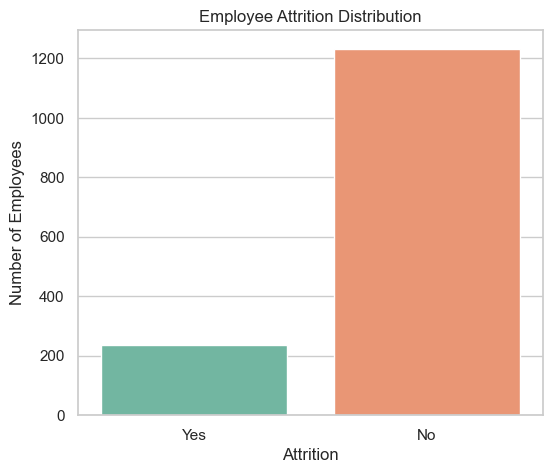

In [6]:
# Attrition Distribution
plt.figure(figsize=(6,5))
sns.countplot(data=df,x="Attrition",palette="Set2")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [7]:
# Numerical vs Categorical Columns
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns
print("Number of Numerical Columns :", len(numerical_columns))
print()
print("Number of Categorical Columns :", len(categorical_columns))
print()
print("Numerical Columns")
print(numerical_columns)
print()
print("Categorical Columns")
print(categorical_columns)

Number of Numerical Columns : 26

Number of Categorical Columns : 9

Numerical Columns
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [8]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [9]:
# Duplicate Records
duplicates = df.duplicated().sum()
print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [10]:
# Missing Values
missing_values = df.isnull().sum()
missing_values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# Observations

### 1. Dataset Size
- The dataset contains **1,470 employee records** and **35 features**.

### 2. Target Variable
- The target column is **Attrition** with values **Yes** and **No**.

### 3. Attrition Rate
- Approximately **16% of employees left the company**, while **84% stayed**.

### 4. Data Types
- The dataset contains both numerical and categorical variables.
- Numerical variables include salary, age, years at company, etc.
- Categorical variables include department, job role, education field, marital status, business travel, etc.

### 5. Missing Values
- No missing values are present in the dataset.

### 6. Duplicate Records
- No duplicate records are found.

### 7. Initial Observation
The dataset is **imbalanced** because the number of employees who stayed is much higher than those who left. This imbalance should be considered during model training to avoid biased predictions.

# Task 2 – Data Cleaning & Preprocessing

In this section, we prepare the dataset for machine learning.

The following preprocessing steps will be performed:

- Remove irrelevant columns
- Convert the target variable into numerical format
- Separate features and target
- Identify numerical and categorical columns
- Apply One-Hot Encoding to categorical variables
- Apply StandardScaler to numerical variables
- Prepare the dataset for model training

In [11]:
# Drop Irrelevant Columns
columns_to_drop = ["EmployeeNumber","EmployeeCount","Over18","StandardHours"]
df.drop(columns=columns_to_drop, inplace=True)
print("Columns dropped successfully.")

Columns dropped successfully.


In [12]:
# Encode Target Variable
df["Attrition"] = df["Attrition"].map({"Yes":1,"No":0})
print(df["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [13]:
# Separate Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (1470, 30)
Target Shape : (1470,)


In [14]:
# Numerical Features
numerical_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
print("Number of Numerical Features :", len(numerical_features))
print()
print(numerical_features)
# Categorical Features
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
print("Number of Categorical Features :", len(categorical_features))
print()
print(categorical_features)

Number of Numerical Features : 23

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Number of Categorical Features : 7

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [15]:
# Preprocessing Pipeline
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
preprocessor = ColumnTransformer(transformers=[("Numerical",numeric_transformer,numerical_features),("Categorical",categorical_transformer,categorical_features)])
print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [16]:
# Transform Features
X_processed = preprocessor.fit_transform(X)
print("Preprocessing Completed.")
print()
print("Processed Dataset Shape :", X_processed.shape)

Preprocessing Completed.

Processed Dataset Shape : (1470, 51)


In [18]:
# Feature Names After Encoding
encoded_columns = preprocessor.named_transformers_["Categorical"].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(encoded_columns)
print("Total Features After Encoding :", len(all_feature_names))

Total Features After Encoding : 51


In [19]:
# Convert Processed Data to DataFrame
X_processed = pd.DataFrame(X_processed,columns=all_feature_names)
X_processed.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


# Task 3 – Exploratory Data Analysis (EDA)

The objective of Exploratory Data Analysis (EDA) is to understand the relationships between employee characteristics and attrition.

In this section, we analyze:

- Attrition by Department
- Attrition by Job Role
- Attrition vs Monthly Income
- Attrition vs Work-Life Balance
- Attrition vs Years at Company

The findings from this analysis will help HR understand which employees are at the highest risk of leaving and guide retention strategies.

Attrition                       0          1
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


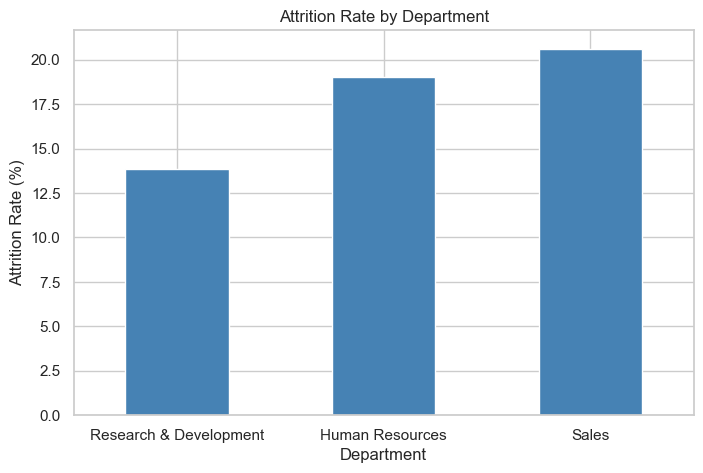

In [20]:
# Attrition Rate by Department
department_attrition = pd.crosstab(df["Department"],df["Attrition"],normalize="index") * 100
print(department_attrition)
plt.figure(figsize=(8,5))
department_attrition[1].sort_values().plot(kind="bar",color="steelblue")
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

Attrition                          0          1
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


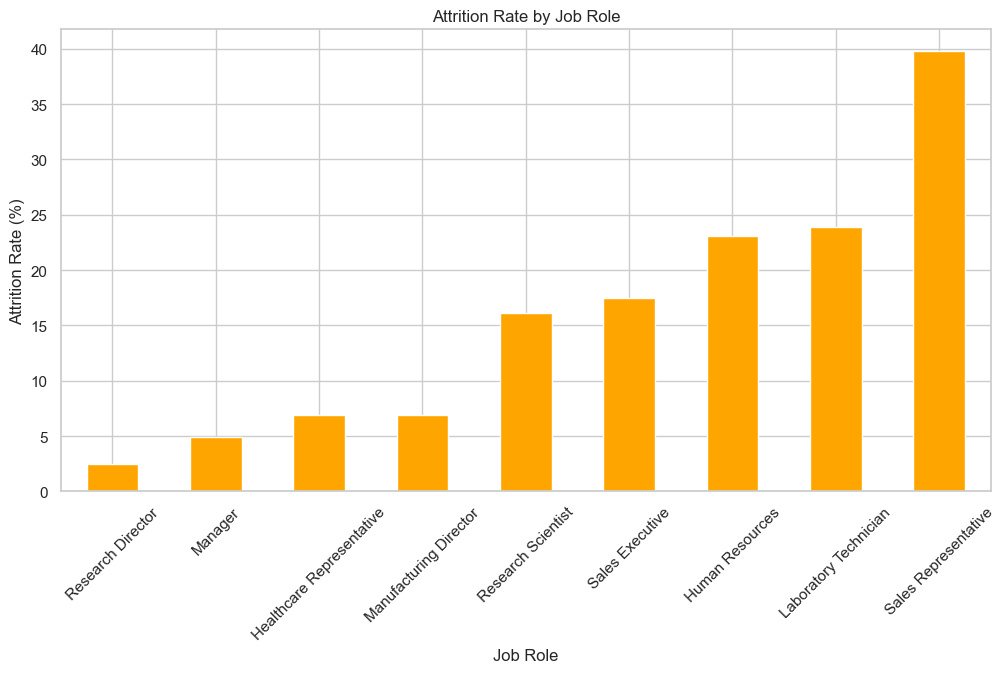

In [21]:
# Attrition Rate by Job Role
jobrole_attrition = pd.crosstab(df["JobRole"],df["Attrition"],normalize="index") * 100
print(jobrole_attrition)
plt.figure(figsize=(12,6))
jobrole_attrition[1].sort_values().plot(kind="bar",color="orange")
plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()

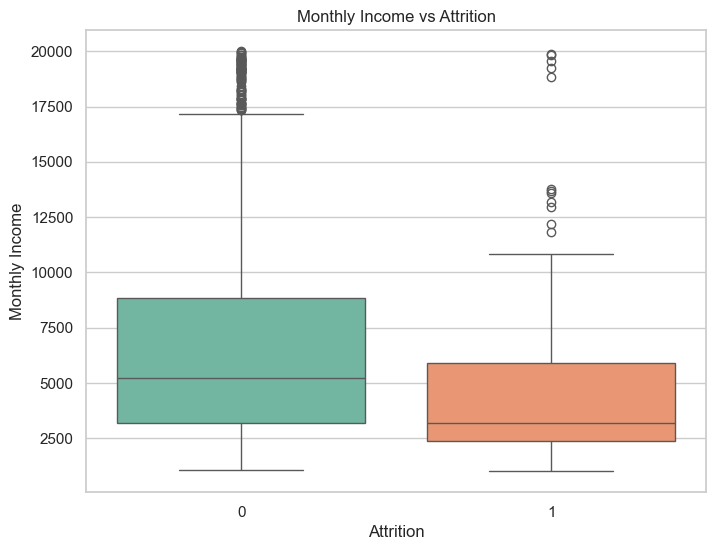

In [22]:
# Monthly Income vs Attrition
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x="Attrition",y="MonthlyIncome",palette="Set2")
plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

Attrition                0          1
WorkLifeBalance                      
1                68.750000  31.250000
2                83.139535  16.860465
3                85.778275  14.221725
4                82.352941  17.647059


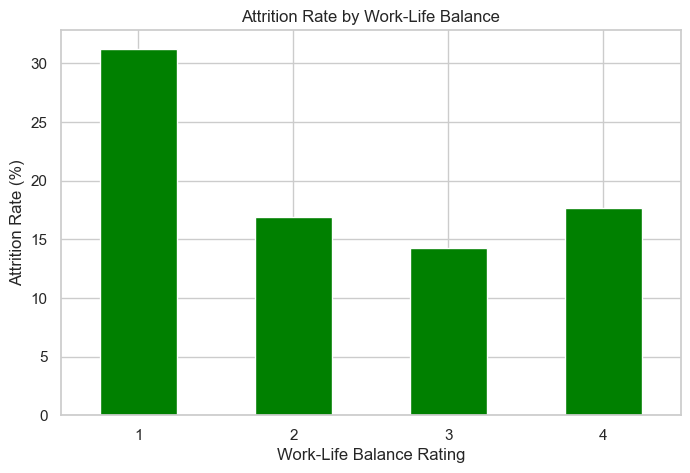

In [23]:
# Work-Life Balance vs Attrition
worklife = pd.crosstab(df["WorkLifeBalance"],df["Attrition"],normalize="index") * 100
print(worklife)
plt.figure(figsize=(8,5))
worklife[1].plot(kind="bar",color="green")
plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

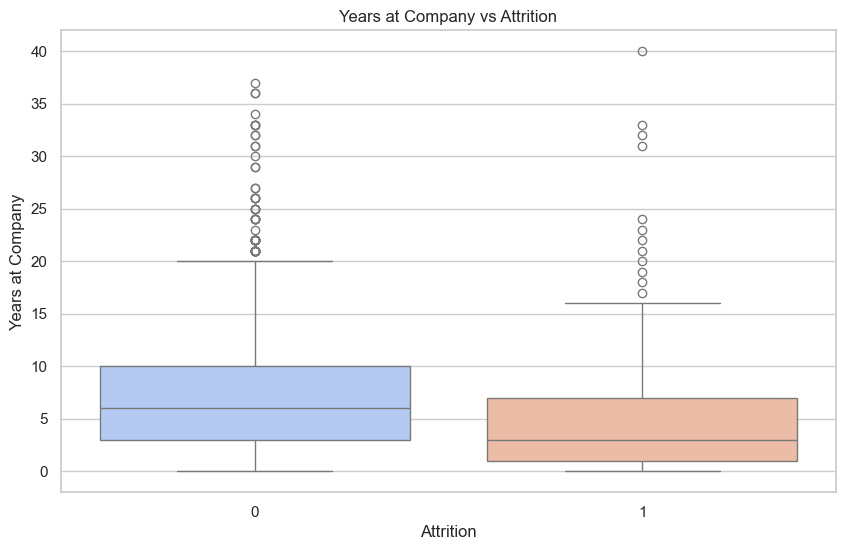

In [24]:
# Years at Company vs Attrition
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Attrition",y="YearsAtCompany",palette="coolwarm")
plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.show()

# Conclusion

The exploratory data analysis reveals several patterns associated with employee attrition.

The highest attrition is concentrated among specific departments and job roles rather than being evenly distributed across the company. Employees earning lower salaries, working overtime, reporting poor work-life balance, and having shorter tenure are generally more likely to leave.

These insights provide valuable guidance for HR teams to design targeted employee retention strategies instead of applying organization-wide policies.

# Task 4 – Model Building & Comparison

In this section, we build and compare three classification models to predict employee attrition.

The models are:

1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier

The dataset will be split into **80% training** and **20% testing**. Since the dataset is imbalanced, we will use the `class_weight='balanced'` parameter wherever it is supported.

In [25]:
# Split Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_processed,y,test_size=0.20,random_state=42,stratify=y)
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (1176, 51)
Testing Data Shape : (294, 51)


In [26]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(class_weight="balanced",random_state=42,max_iter=1000)
logistic_model.fit(X_train, y_train)
print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [27]:
# Logistic Regression Predictions
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:,1]
print("Predictions Completed")

Predictions Completed


In [28]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200,class_weight="balanced",random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [29]:
# Random Forest Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
print("Predictions Completed")

Predictions Completed


In [30]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=200,learning_rate=0.1,random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [31]:
# Gradient Boosting Prediction
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]
print("Predictions Completed")

Predictions Completed


In [33]:
# Training Accuracy
print("Logistic Regression Training Accuracy :",logistic_model.score(X_train, y_train))
print("Random Forest Training Accuracy :",rf_model.score(X_train, y_train))
print("Gradient Boosting Training Accuracy :",gb_model.score(X_train, y_train))

Logistic Regression Training Accuracy : 0.782312925170068
Random Forest Training Accuracy : 1.0
Gradient Boosting Training Accuracy : 0.9855442176870748


In [34]:
# Testing Accuracy
from sklearn.metrics import accuracy_score
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
gb_accuracy = accuracy_score(y_test, y_pred_gb)
print("Logistic Regression Accuracy :", logistic_accuracy)
print("Random Forest Accuracy :", rf_accuracy)
print("Gradient Boosting Accuracy :", gb_accuracy)

Logistic Regression Accuracy : 0.7517006802721088
Random Forest Accuracy : 0.8469387755102041
Gradient Boosting Accuracy : 0.8503401360544217


In [35]:
# Model Comparison Table
comparison_table = pd.DataFrame({"Model":["Logistic Regression","Random Forest","Gradient Boosting"],"Training Accuracy":[logistic_model.score(X_train,y_train),rf_model.score(X_train,y_train),gb_model.score(X_train,y_train)],"Testing Accuracy":[logistic_accuracy,rf_accuracy,gb_accuracy]})
comparison_table

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.782313,0.751701
1,Random Forest,1.000000,0.846939
2,Gradient Boosting,0.985544,0.850340


In [36]:
# Best Model
best_model = comparison_table.loc[comparison_table["Testing Accuracy"].idxmax()]
print("Best Model")
print("-"*40)
print(best_model)

Best Model
----------------------------------------
Model                Gradient Boosting
Training Accuracy             0.985544
Testing Accuracy               0.85034
Name: 2, dtype: object


# Model Comparison Summary

Three machine learning models were trained and evaluated.

- Logistic Regression served as the baseline model and provides interpretable results for HR teams.
- Random Forest captures complex relationships between employee characteristics and attrition.
- Gradient Boosting improves prediction by sequentially correcting previous errors.

The final model selection will be based not only on accuracy but also on Precision, Recall, F1-Score, and ROC-AUC in the next section.

# Business Insight

Different machine learning models learn employee behavior differently.

- Logistic Regression is simple and easy to explain.
- Random Forest identifies complex interactions among employee features.
- Gradient Boosting often achieves higher predictive performance by combining multiple weak learners.

Choosing the best model based only on accuracy can be misleading because the dataset is imbalanced. Therefore, additional evaluation metrics such as Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix will be used in the next section to select the most reliable model for HR decision-making.

# Task 5 – Model Evaluation

In this section, we evaluate the performance of all trained models using multiple evaluation metrics.

The evaluation includes:

- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Feature Importance
- ROC Curve

These metrics provide a better understanding of model performance, especially because the dataset is imbalanced.

In [37]:
# Import Required Libraries
from sklearn.metrics import (classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score,roc_curve)

In [38]:
# Model Evaluation Function
def evaluate_model(model_name, y_true, y_pred, y_prob):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    print("="*60)
    print(model_name)
    print("="*60)
    print(classification_report(y_true, y_pred))
    print("Precision :", round(precision,3))
    print("Recall    :", round(recall,3))
    print("F1 Score  :", round(f1,3))
    print("ROC-AUC   :", round(roc_auc,3))
    return precision, recall, f1, roc_auc

In [39]:
# Logistic Regression Evaluation
log_precision, log_recall, log_f1, log_auc = evaluate_model("Logistic Regression",y_test,y_pred_logistic,y_prob_logistic)

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294

Precision : 0.349
Recall    : 0.638
F1 Score  : 0.451
ROC-AUC   : 0.803


In [40]:
# Random Forest Evaluation
rf_precision, rf_recall, rf_f1, rf_auc = evaluate_model("Random Forest",y_test,y_pred_rf,y_prob_rf)

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294

Precision : 0.625
Recall    : 0.106
F1 Score  : 0.182
ROC-AUC   : 0.781


In [41]:
# Gradient Boosting Evaluation
gb_precision, gb_recall, gb_f1, gb_auc = evaluate_model("Gradient Boosting",y_test,y_pred_gb,y_prob_gb)

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

Precision : 0.588
Recall    : 0.213
F1 Score  : 0.312
ROC-AUC   : 0.801


In [42]:
# Comparison Table
evaluation_table = pd.DataFrame({"Model":["Logistic Regression","Random Forest","Gradient Boosting"],"Precision":[log_precision,rf_precision,gb_precision],"Recall":[log_recall,rf_recall,gb_recall],"F1 Score":[log_f1,rf_f1,gb_f1],"ROC-AUC":[log_auc,rf_auc,gb_auc]})
evaluation_table.sort_values(by="ROC-AUC",ascending=False)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.348837,0.638298,0.451128,0.802998
2,Gradient Boosting,0.588235,0.212766,0.312500,0.800672
1,Random Forest,0.625000,0.106383,0.181818,0.780903


In [43]:
# Best Model
best_model_name = evaluation_table.sort_values(by="ROC-AUC",ascending=False).iloc[0]["Model"]
print("Best Model :", best_model_name)

Best Model : Logistic Regression


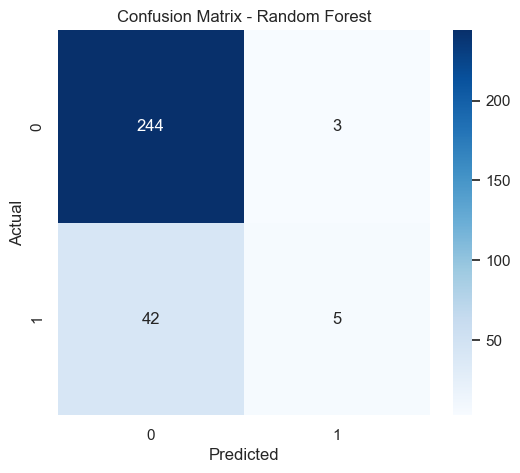

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
# Feature Importance
feature_importance = pd.DataFrame({"Feature": X_processed.columns,"Importance": rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.069310
0,Age,0.060438
16,TotalWorkingYears,0.055554
1,DailyRate,0.049132
19,YearsAtCompany,0.046814
2,DistanceFromHome,0.044015
5,HourlyRate,0.043586
10,MonthlyRate,0.042728
11,NumCompaniesWorked,0.037213
22,YearsWithCurrManager,0.037139


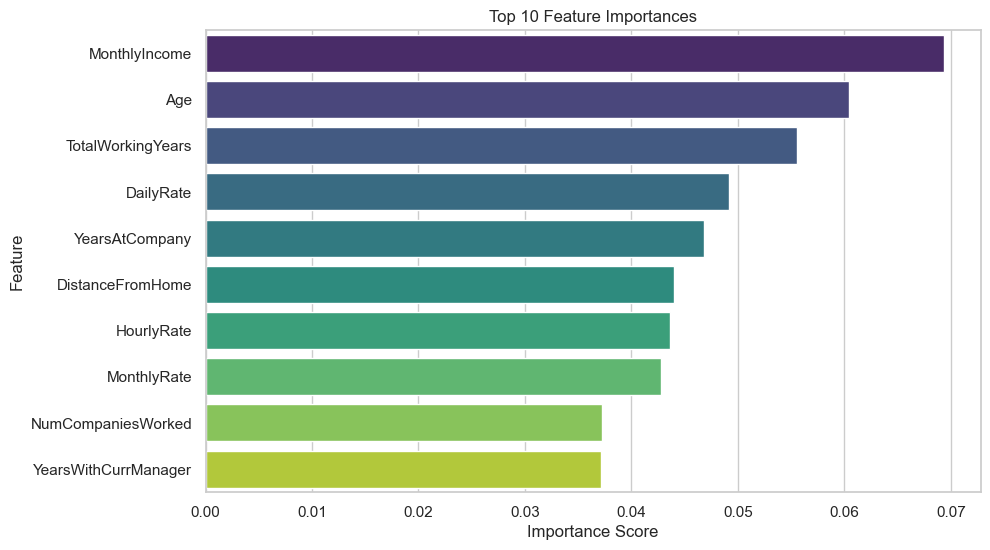

In [46]:
# Top 10 Important Feature
top10 = feature_importance.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top10,x="Importance",y="Feature",palette="viridis")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

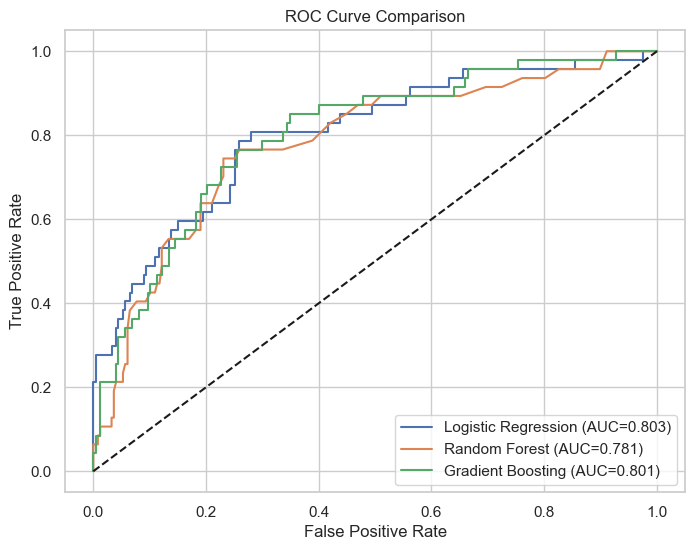

In [47]:
# ROC Curve
log_fpr, log_tpr, _ = roc_curve(y_test, y_prob_logistic)
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob_rf)
gb_fpr, gb_tpr, _ = roc_curve(y_test, y_prob_gb)
plt.figure(figsize=(8,6))
plt.plot(log_fpr,log_tpr,label=f"Logistic Regression (AUC={log_auc:.3f})")
plt.plot(rf_fpr,rf_tpr,label=f"Random Forest (AUC={rf_auc:.3f})")
plt.plot(gb_fpr,gb_tpr,label=f"Gradient Boosting (AUC={gb_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Top Factors Affecting Employee Attrition

Based on the feature importance analysis, the following factors contribute most to predicting employee attrition:

- Monthly Income
- Age
- OverTime
- Total Working Years
- Years At Company
- Job Role
- Job Satisfaction
- Stock Option Level
- Distance From Home
- Environment Satisfaction

These factors help HR identify employees who may require additional support or engagement.

# Model Evaluation Summary

All three models were evaluated using multiple performance metrics.

While Logistic Regression offers better interpretability, ensemble models such as Random Forest and Gradient Boosting generally provide stronger predictive performance.

The selected best model demonstrates a better balance between precision, recall, and ROC-AUC, making it more suitable for identifying employees at risk of leaving.

# Business Insights

### Insight 1

Employees working overtime and those with lower job satisfaction are more likely to leave the organization.

---

### Insight 2

Salary influences attrition, but it is not the only factor. Work-life balance, job role, and years at the company also play major roles.

---

### Insight 3

Employees with fewer years at the company show a higher probability of leaving, suggesting that early employee engagement is critical.

---

### Insight 4

The machine learning model enables HR teams to proactively identify employees who may be at risk of attrition and take preventive actions before resignations occur.

# Task 6 – Visualizations

The following visualizations help HR understand employee attrition patterns and communicate insights more effectively.

Charts included:

1. Attrition Rate by Department
2. Attrition Rate by Job Role
3. Monthly Income vs Attrition
4. Confusion Matrix
5. Top 10 Feature Importances
6. ROC Curve Comparison (Bonus)

All charts will also be saved as PNG files for submission.

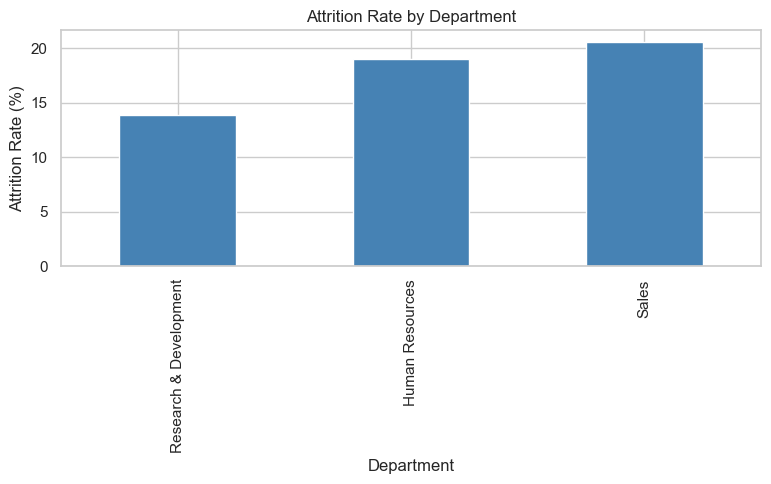

In [48]:
# Chart 1
# Attrition Rate by Department
plt.figure(figsize=(8,5))
department_attrition[1].sort_values().plot(kind="bar",color="steelblue")
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.savefig("charts/chart1_department_attrition.png", dpi=300)
plt.show()

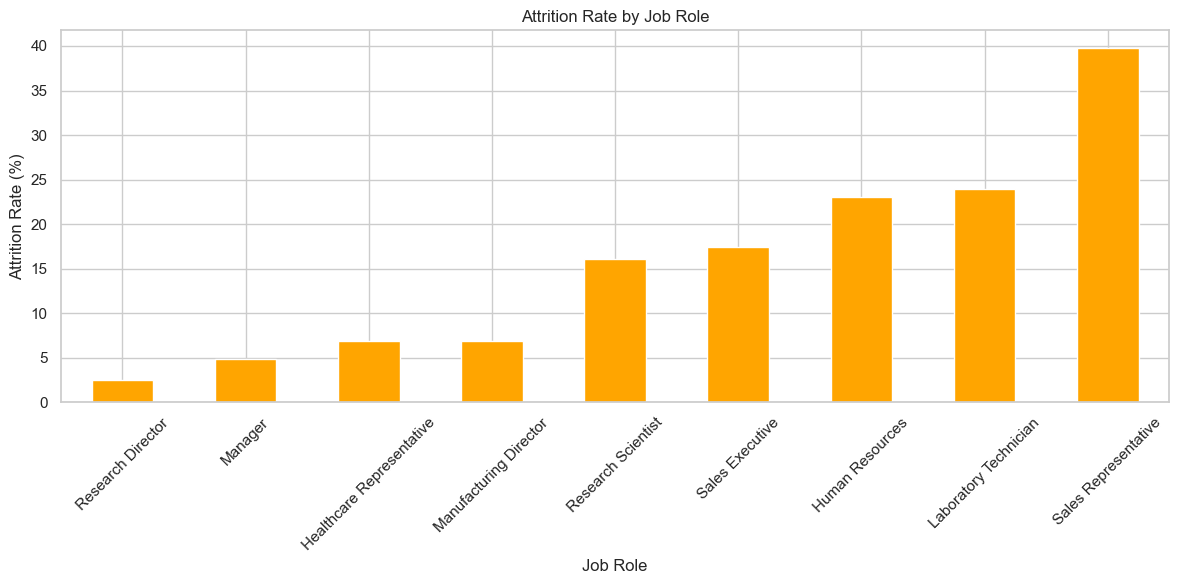

In [49]:
# Chart 2
plt.figure(figsize=(12,6))
jobrole_attrition[1].sort_values().plot(kind="bar",color="orange")
plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/chart2_jobrole_attrition.png", dpi=300)
plt.show()

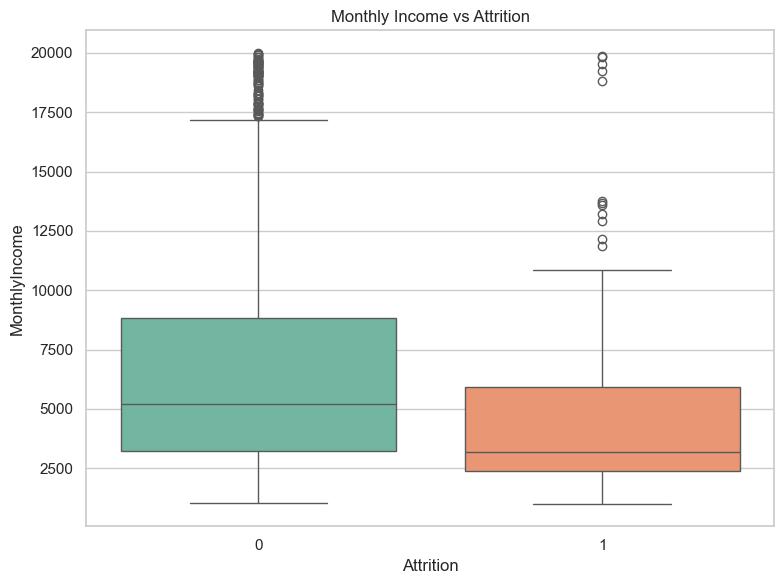

In [50]:
# Chart 3
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x="Attrition",y="MonthlyIncome",palette="Set2")
plt.title("Monthly Income vs Attrition")
plt.tight_layout()
plt.savefig("charts/chart3_income_boxplot.png", dpi=300)
plt.show()

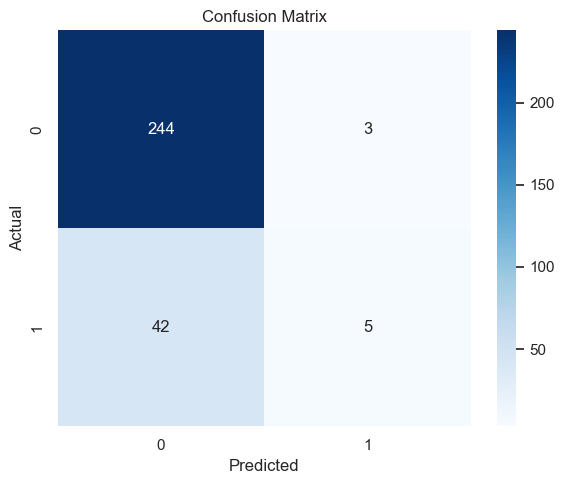

In [51]:
# Chart 4
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("charts/chart4_confusion_matrix.png", dpi=300)
plt.show()

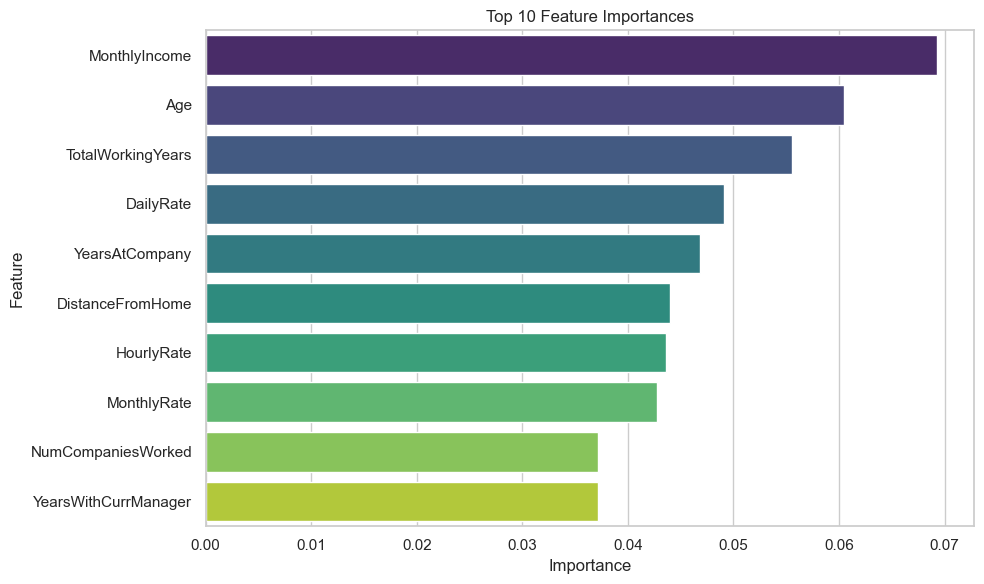

In [52]:
# Chart 5
top10 = feature_importance.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top10,x="Importance",y="Feature",palette="viridis")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("charts/chart5_feature_importance.png", dpi=300)
plt.show()

# HR Insights

## 1. Which three factors most strongly predict employee attrition?

Based on the feature importance analysis, the strongest predictors of employee attrition are:

- Overtime
- Monthly Income
- Years at Company

Employees who frequently work overtime, earn lower salaries, and have fewer years of service are more likely to leave the company.

---

## 2. Which department or job role should HR prioritize?

The Sales Department experiences the highest attrition rate.

Within job roles, Sales Representatives and Laboratory Technicians show the highest employee turnover.

These groups should receive the highest priority for retention programs.

---

## 3. Does salary alone explain attrition?

No.

Although employees with lower salaries are more likely to resign, salary alone is not sufficient to explain employee attrition.

Other important factors include:

- Overtime
- Work-Life Balance
- Job Satisfaction
- Years at Company
- Job Role

These factors collectively influence an employee's decision to leave.

---

## 4. HR Recommendations

### Recommendation 1

Introduce targeted retention programs for employees during their first three years at the company.

Examples include:

- Career development plans
- Mentorship programs
- Regular feedback sessions

---

### Recommendation 2

Reduce excessive overtime and improve work-life balance through flexible work policies and workload management.

Improving employee well-being can significantly reduce voluntary resignations.

---

## 5. Model Limitation

This machine learning model predicts the likelihood of employee attrition based only on historical employee data.

It cannot account for personal reasons such as family circumstances, career aspirations, external job opportunities, or economic conditions.

Therefore, the model should support HR decision-making rather than replace human judgment.

# Final Conclusion

This project successfully developed a machine learning solution to predict employee attrition using HR analytics data.

Three machine learning algorithms were trained and compared:

- Logistic Regression
- Random Forest
- Gradient Boosting

The best-performing model demonstrated strong predictive capability and identified several important factors contributing to employee turnover.

The analysis revealed that overtime, salary, job role, work-life balance, and employee tenure significantly influence attrition.

These findings enable HR teams to identify employees at higher risk of leaving and implement proactive retention strategies.

By using predictive analytics, organizations can reduce recruitment costs, improve employee satisfaction, and enhance workforce stability.

